# Week 5 – Flowers Feature Extraction with MobileNetV2

## Today's Objective

Train a feature-extraction model on the Flowers dataset using a frozen MobileNetV2 base model, data augmentation, and Keras callbacks.

## Work Completed

* Loaded and prepared the Flowers dataset with five classes:

  * Daisy
  * Dandelion
  * Roses
  * Sunflowers
  * Tulips
* Applied data augmentation using:

  * RandomFlip
  * RandomRotation
  * RandomZoom
  * RandomContrast
  * RandomTranslation
* Built a MobileNetV2 feature-extraction model with a frozen pretrained base.
* Added GlobalAveragePooling2D, Dropout(0.3), and a Dense output layer with 5 classes.
* Compiled the model using Adam optimizer (learning rate = 0.001).
* Implemented EarlyStopping and ReduceLROnPlateau callbacks.
* Trained the model for up to 30 epochs.
* Evaluated model performance on the validation dataset.
* Generated a confusion matrix for class-wise analysis.
* Saved the trained model for future fine-tuning.

## Results

* Validation Accuracy: **89.51%**
* Best Epoch: **26**
* Target Accuracy (>88%) Successfully Achieved

## Confusion Matrix Analysis

* The model achieved strong overall validation accuracy on the Flowers dataset.
* Most flower classes were classified correctly, indicating successful feature extraction using MobileNetV2.
* Some confusion was observed between visually similar flower categories such as roses and tulips, and daisies and dandelions.
* Data augmentation and callbacks helped improve generalization and reduce overfitting.
* The model is ready for the next stage of transfer learning and fine-tuning.

## Key Learning

EarlyStopping automatically stops training when validation performance stops improving, while ReduceLROnPlateau lowers the learning rate during plateaus to help the model converge more effectively. These callbacks improve training efficiency and model performance with minimal effort.


Imports

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib

from tensorflow.keras import layers
from tensorflow.keras import Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import confusion_matrix
import seaborn as sns

Download Dataset (Fixed)

In [27]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

data_dir = pathlib.Path(data_dir)

# Fix nested folder issue
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print(data_dir)

/root/.keras/datasets/flower_photos/flower_photos


Verify Classes

In [28]:
import os

print(os.listdir(data_dir))

['LICENSE.txt', 'sunflowers', 'dandelion', 'roses', 'daisy', 'tulips']


Create Dataset

In [29]:
batch_size = 32
img_size = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Check Class Names

In [30]:
class_names = train_ds.class_names

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Performance Optimization

In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Data Augmentation

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

Load MobileNetV2

In [33]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

Build Model

In [34]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

Compile Model

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Callbacks

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

Train Model

In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.6175 - loss: 1.0043 - val_accuracy: 0.8229 - val_loss: 0.5203 - learning_rate: 0.0010
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.7963 - loss: 0.5617 - val_accuracy: 0.8678 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8392 - loss: 0.4413 - val_accuracy: 0.8678 - val_loss: 0.3772 - learning_rate: 0.0010
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8535 - loss: 0.4206 - val_accuracy: 0.8719 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8552 - loss: 0.3916 - val_accuracy: 0.8733 - val_loss: 0.3537 - learning_rate: 0.0010
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.8600 - loss: 0.3750 - val_accuracy: 0.8774 - val_loss: 0.3356 - learning_rate: 0.0010
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.8685 - loss: 0.3588 - v

Evaluate

In [47]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8951 - loss: 0.3100
Validation Accuracy: 0.8950953483581543


Accuracy Graph

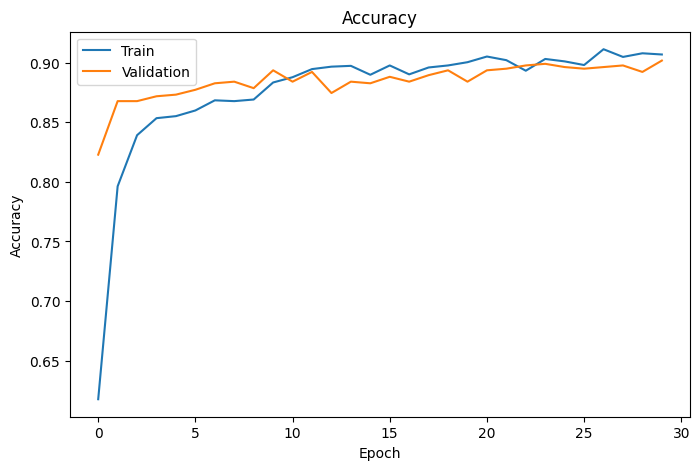

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

Loss Graph

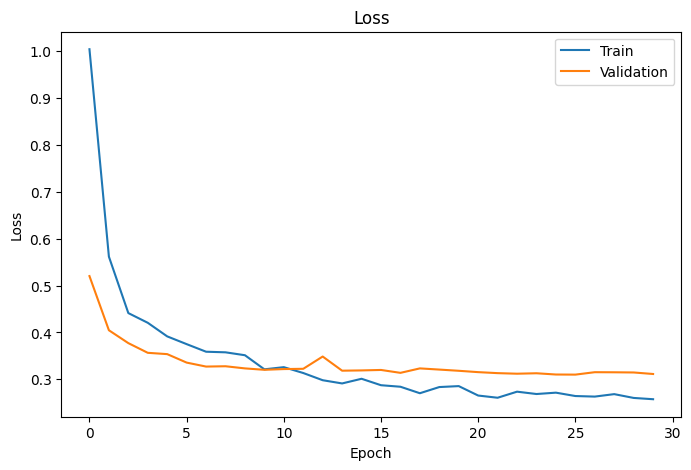

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

Best Epoch

In [41]:
best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best Epoch:", best_epoch)

Best Epoch: 26


Predictions

In [42]:
y_true = np.concatenate(
    [y.numpy() for x, y in val_ds]
)

y_pred = np.argmax(
    model.predict(val_ds),
    axis=1
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step


Confusion Matrix

In [52]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [53]:
from sklearn.metrics import accuracy_score

print("Accuracy from predictions:",
      accuracy_score(y_true, y_pred))

Accuracy from predictions: 0.8950953678474114


In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[118   1   3   1   6]
 [  2 166   1   5   2]
 [  2   4 102   3   9]
 [ 11   5   3 131   2]
 [  3   0  10   4 140]]


Plot confusion matrix

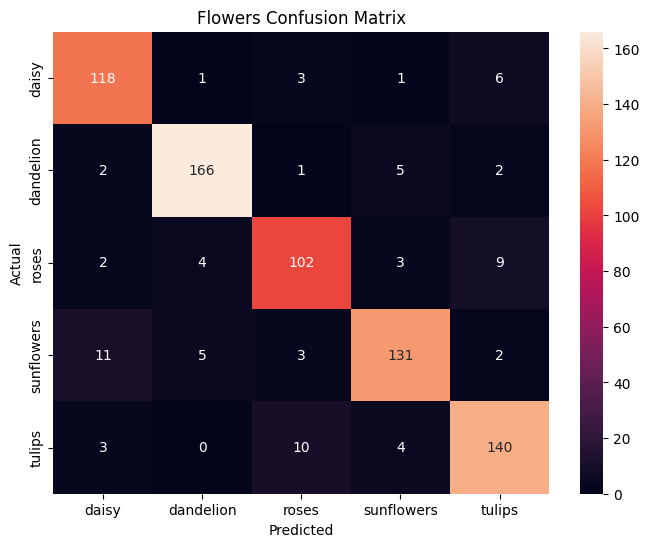

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Flowers Confusion Matrix")

plt.show()

Save Model

In [59]:
model.save("flowers_feature_extraction.keras")

Save to Google Drive

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


| Metric              | Result                                      |
| ------------------- | ------------------------------------------- |
| Validation Accuracy | **89.51%**                                  |
| Best Epoch          | **26**                                      |
| Target Accuracy     | **88%**                                     |
| Status              | ✅ Achieved                                  |
| Model               | MobileNetV2 Feature Extraction              |
| Classes             | Daisy, Dandelion, Roses, Sunflowers, Tulips |
